# Criminalidade urbana no Rio Grande do Sul — análise por município

**Trabalho Final de Ciência de Dados — Tema 6.** Pergunta central: os tipos de
ocorrência têm padrão espacial (município / mesorregião) e temporal (dia,
horário) identificável no RS, a ponto de justificar priorização de recursos por
região?

**Fontes:** microdados de ocorrências da SSP-RS (2022–2025) e IBGE (Censo 2022,
população e mesorregiões). Preparação dos dados: `src/carga.py`, `src/ibge.py`,
`src/limpeza.py`.

## 1. Carga dos dados

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import viz
viz.aplicar_estilo()

df = pd.read_parquet(RAIZ / "data" / "interim" / "ocorrencias_rs.parquet")
mun = pd.read_csv(RAIZ / "data" / "processed" / "municipios_taxa.csv")

# Reaplica a ordem das categorias temporais (o parquet pode perder o ordenamento).
df["nome_dia"] = pd.Categorical(df["nome_dia"], categories=viz.ORDEM_DIA, ordered=True)
df["turno"] = pd.Categorical(df["turno"], categories=viz.ORDEM_TURNO, ordered=True)

n_anos = df["ano"].nunique()
print(f"Ocorrencias: {len(df):,} | anos: {sorted(df['ano'].unique())} | "
      f"municipios: {df['municipio'].nunique()}")

Ocorrencias: 3,117,592 | anos: [np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)] | municipios: 497


## 2. Análise exploratória (descritiva)

In [2]:
# Composicao por macrocategoria e recorte de crimes de rua (sensiveis a patrulha).
resumo = (df["macro"].value_counts(normalize=True) * 100).round(1)
print("Participacao por macrocategoria (%):")
print(resumo.to_string())
print(f"\nCrimes de rua: {df['crime_de_rua'].mean():.1%} das ocorrencias")

rua = df[df["crime_de_rua"]].copy()
print(f"Ocorrencias de crime de rua: {len(rua):,}")

Participacao por macrocategoria (%):
macro
AMEACA_VD             17.6
FRAUDE                17.2
OUTROS                13.0
FURTO_OUTROS          12.0
LESAO                  8.9
TRANSITO               6.7
HONRA_DISCRIM          4.5
DROGAS                 3.9
ORDEM_PUBLICA          3.1
ROUBO_RUA              2.6
DANO                   2.6
FURTO_VEICULO          2.2
FURTO_ARROMBAMENTO     1.8
ROUBO_OUTROS           1.4
SEXUAL                 1.1
ARMAS                  0.9
ROUBO_VEICULO          0.4
CVLI                   0.2

Crimes de rua: 33.4% das ocorrencias


Ocorrencias de crime de rua: 1,041,007


### 3. Quando o crime acontece — Figura 1

Heatmap de ocorrências de crime de rua por dia da semana × hora do dia.
Responde: existe concentração em faixas de horário/dia?

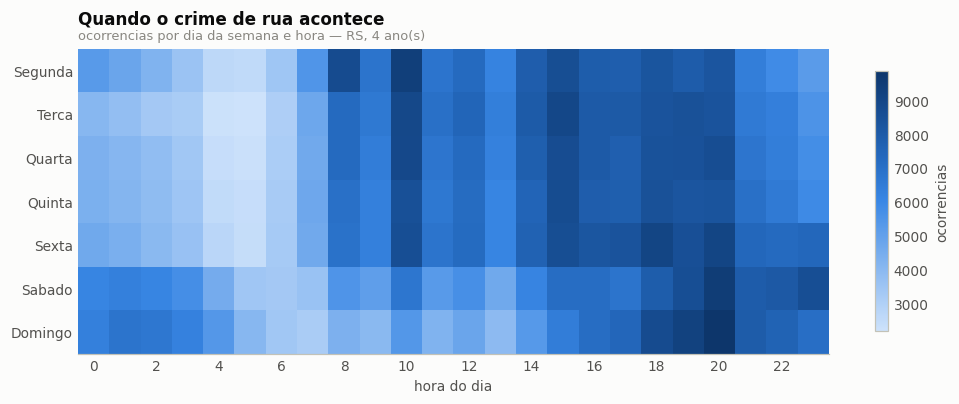

In [3]:
piv = (rua.pivot_table(index="nome_dia", columns="hora", aggfunc="size", observed=False)
          .reindex(index=viz.ORDEM_DIA).reindex(columns=range(24), fill_value=0).fillna(0))

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(piv.values, aspect="auto", cmap=viz.CMAP)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(range(0, 24, 2))
ax.set_yticks(range(7)); ax.set_yticklabels(viz.ORDEM_DIA)
ax.set_xlabel("hora do dia")
viz.limpar_grade(ax)
viz.titular(ax, "Quando o crime de rua acontece",
            f"ocorrencias por dia da semana e hora — RS, {n_anos} ano(s)")
fig.colorbar(im, ax=ax, shrink=0.85, label="ocorrencias")
viz.salvar(fig, "f1_heatmap_dia_hora"); plt.show()

### 4. Cada crime tem sua hora — Figura 2

Distribuição horária normalizada das principais macrocategorias. Responde: o
horário de pico depende do tipo de crime?

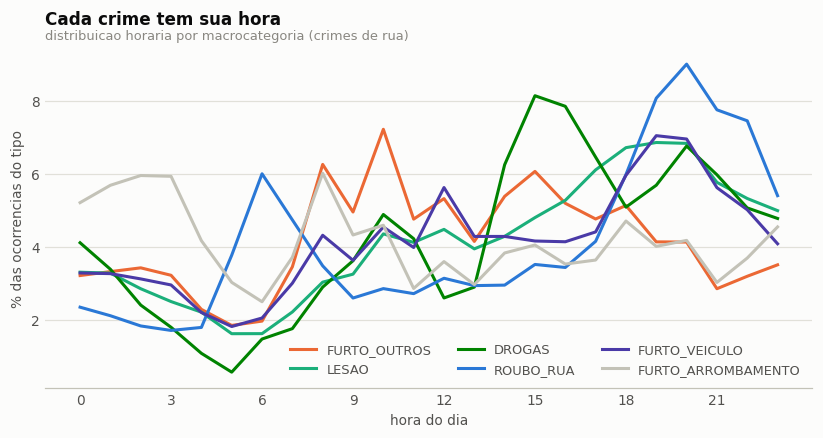

In [4]:
top = rua["macro"].value_counts().head(6).index
fig, ax = plt.subplots(figsize=(9, 4))
for m in top:
    s = (rua.loc[rua["macro"] == m, "hora"].value_counts(normalize=True)
            .reindex(range(24), fill_value=0).sort_index())
    ax.plot(s.index, s.values * 100, label=m, color=viz.cor_macro(m))
ax.set_xlabel("hora do dia"); ax.set_ylabel("% das ocorrencias do tipo")
ax.set_xticks(range(0, 24, 3))
ax.legend(ncol=3)
viz.titular(ax, "Cada crime tem sua hora",
            "distribuicao horaria por macrocategoria (crimes de rua)")
viz.salvar(fig, "f2_perfil_horario_por_tipo"); plt.show()

### 5. Onde a taxa é maior — Figura 3

Taxa média anual por 100 mil habitantes, top 15 municípios. **Atenção:** a
população é a residente (Censo 2022); municípios litorâneos aparecem inflados
pela população flutuante de veraneio — ver limitações.

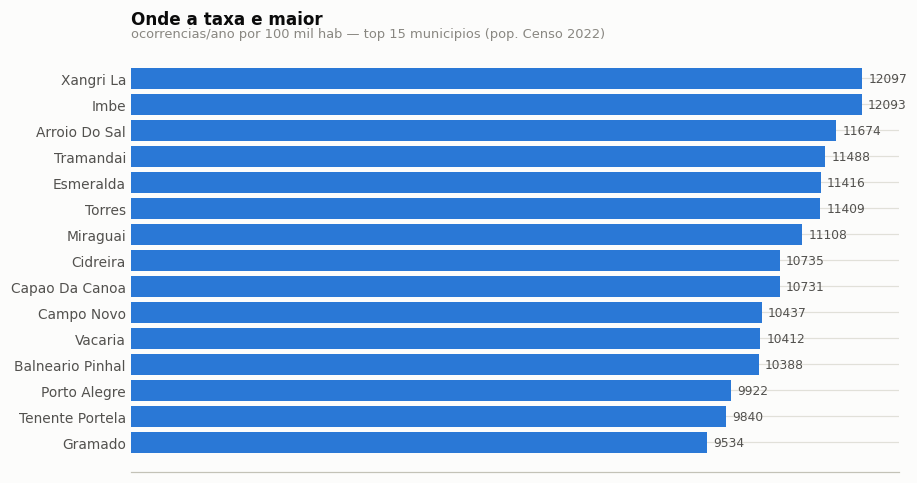

In [5]:
top15 = mun.sort_values("taxa_100k", ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15["municipio"].str.title(), top15["taxa_100k"], color=viz.SERIES[0])
viz.rotular_barras(ax, "{:.0f}", horizontal=True)
viz.titular(ax, "Onde a taxa e maior",
            "ocorrencias/ano por 100 mil hab — top 15 municipios (pop. Censo 2022)")
viz.salvar(fig, "f3_taxa_municipio"); plt.show()

### 6. Intensidade por mesorregião — Figura 4

Taxa média anual por 100 mil hab. por mesorregião (ponderada pela população).
Responde: a intensidade varia entre regiões do estado?

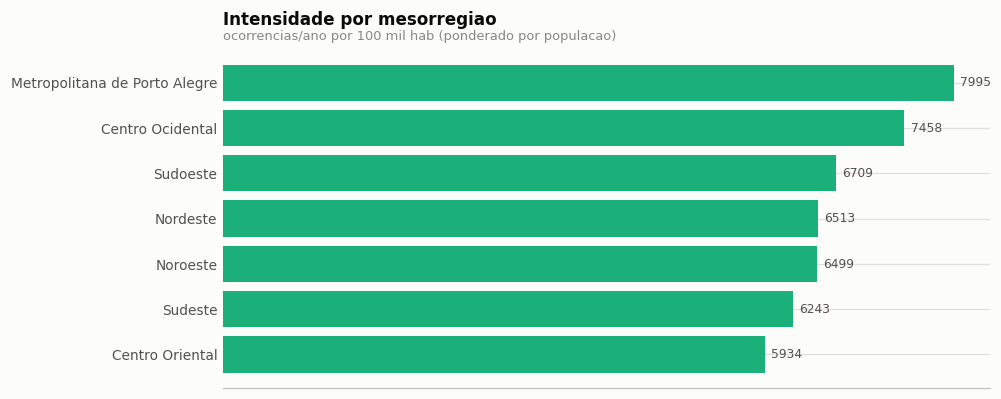

In [6]:
reg = (mun.groupby("mesorregiao")
          .agg(occ=("n_ocorrencias", "sum"), pop=("populacao", "sum"))
          .reset_index())
reg["taxa"] = reg["occ"] / reg["pop"] / n_anos * 1e5
reg = reg.sort_values("taxa")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(reg["mesorregiao"].str.replace(" Rio-grandense", "", regex=False),
        reg["taxa"], color=viz.SERIES[2])
viz.rotular_barras(ax, "{:.0f}", horizontal=True)
viz.titular(ax, "Intensidade por mesorregiao",
            "ocorrencias/ano por 100 mil hab (ponderado por populacao)")
viz.salvar(fig, "f4_taxa_mesorregiao"); plt.show()

## 7. Teste de hipóteses — o padrão temporal é real?

**Qui-quadrado de independência** entre macrocategoria e turno (crimes de rua).
$H_0$: o tipo de ocorrência é independente do turno (o padrão seria acaso).

In [7]:
ct = pd.crosstab(rua["macro"], rua["turno"])
chi2, p, dof, exp = chi2_contingency(ct)
n = ct.values.sum()
cramer_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"chi2 = {chi2:,.1f} | gl = {dof} | p = {p:.3e} | V de Cramer = {cramer_v:.3f}")
print("H0 rejeitada" if p < 0.05 else "H0 nao rejeitada")

chi2 = 40,606.6 | gl = 24 | p = 0.000e+00 | V de Cramer = 0.114
H0 rejeitada


### Figura 5 — onde o padrão foge do acaso

Resíduos padronizados do χ²: células azuis ocorrem **menos** que o esperado sob
independência; vermelhas, **mais**. Mostra qual crime concentra em qual turno.

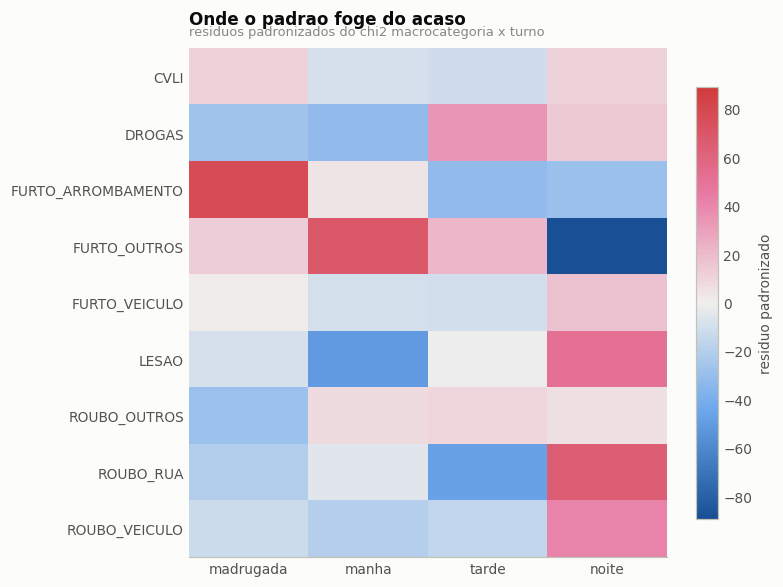

In [8]:
resid = (ct - exp) / np.sqrt(exp)
vmax = np.abs(resid.values).max()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(resid.values, cmap=viz.CMAP_DIVERGENTE, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
viz.limpar_grade(ax)
fig.colorbar(im, ax=ax, shrink=0.85, label="residuo padronizado")
viz.titular(ax, "Onde o padrao foge do acaso",
            "residuos padronizados do chi2 macrocategoria x turno")
viz.salvar(fig, "f5_residuos_chi2"); plt.show()

## 8. O perfil de crime difere entre regiões?

Dois testes complementares:
- **χ² macrocategoria × mesorregião**: a composição de crimes muda por região?
- **Kruskal-Wallis**: a taxa por 100 mil hab. dos municípios difere entre as
  mesorregiões? (não-paramétrico, não assume normalidade)

In [9]:
ct2 = pd.crosstab(rua["macro"], rua["mesorregiao"])
chi2b, pb, dofb, _ = chi2_contingency(ct2)
vb = np.sqrt(chi2b / (ct2.values.sum() * (min(ct2.shape) - 1)))
print(f"[chi2 macro x mesorregiao] chi2 = {chi2b:,.1f} | gl = {dofb} | "
      f"p = {pb:.3e} | V = {vb:.3f}")

grupos = [g["taxa_100k"].dropna().values for _, g in mun.groupby("mesorregiao")]
H, pk = kruskal(*grupos)
print(f"[Kruskal-Wallis taxa/100k por mesorregiao] H = {H:.1f} | p = {pk:.3e}")

[chi2 macro x mesorregiao] chi2 = 50,367.6 | gl = 48 | p = 0.000e+00 | V = 0.090
[Kruskal-Wallis taxa/100k por mesorregiao] H = 30.3 | p = 3.414e-05


## 9. Conclusão e recomendação

_(preencher com os números acima, no formato: "portanto, a recomendação é Y, com
a ressalva Z")_

- **Padrão temporal:** χ² macro × turno (§7) confirma/rejeita associação.
- **Padrão espacial:** taxa por município (§5) e mesorregião (§6) + testes (§8).
- **Recomendação:** priorizar as regiões/turnos de maior taxa e concentração.
- **Ressalvas:** ocorrência registrada ≠ crime real (subnotificação); população
  de referência é o Censo 2022 (municípios de veraneio inflam a taxa); municípios
  pequenos têm taxa instável.